In [12]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

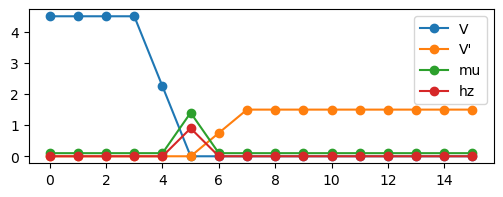

In [13]:
widthD = 5
widthF = 1
widthP = 10

X, Y = widthD+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.386

muD = 0.1 * t
muP = 0.1 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

U = None

V0 = 4.5 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0 
V_prime[widthF+widthD] = V_prime0/2


plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

In [14]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=h)

In [15]:
bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=1000, temperature=T)


Converged after 587 iterations


(array([ 2.22674464e-01-7.66162926e-05j,  1.21440496e-01-4.21200473e-05j,
        -1.89891884e-01+5.88431300e-05j,  1.85613774e-01-2.42392772e-04j,
         2.25982101e-01-2.74197885e-04j,  2.07519217e-04-3.45331326e-04j,
         3.07131431e-06+2.46857521e-05j,  1.22337906e-06-2.10045028e-05j,
         2.02918583e-07-2.39012561e-06j,  4.44516741e-08+2.31797045e-06j,
         1.24622481e-08+1.18145919e-07j,  3.06235815e-09-9.99264405e-08j,
         7.61317993e-10-8.35293411e-09j,  1.93109142e-10+1.87800738e-09j,
         4.59719225e-11-7.22760685e-11j,  1.56109880e-11-1.11500111e-10j]),
 array([ 1.63379318e-01-5.19757862e-05j,  2.99880244e-01-9.72791837e-05j,
         2.49799575e-01-7.73511135e-05j,  2.88340856e-01-2.88619144e-04j,
         2.23446661e-01-2.13054576e-04j, -1.41843560e-04+4.60764796e-05j,
        -6.46301762e-05-3.95043529e-04j, -1.69096263e-05+2.63872420e-05j,
        -4.28580222e-06+5.16072161e-05j, -9.83743023e-07+5.47769125e-06j,
        -2.26551170e-07-1.41102902e-

In [16]:
F, Fuu, Fdd = H.get_correlations()


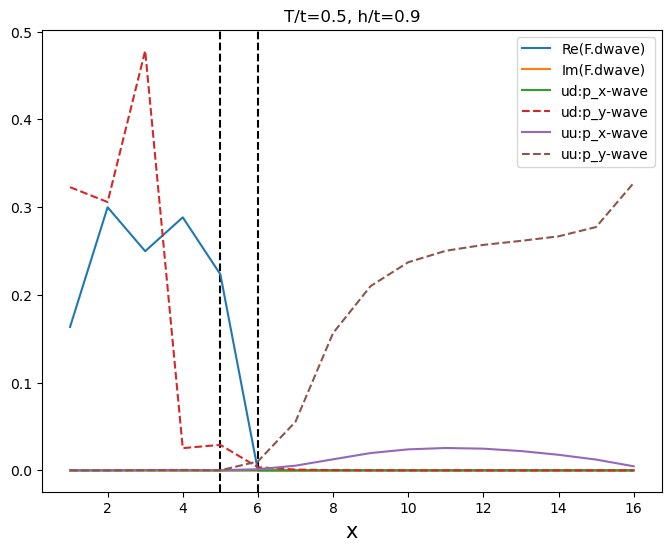

In [23]:
x = np.arange(1, widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, h/t={h0}")
axs.axvline(widthD, color='black', linestyle='--')
axs.axvline(widthD+widthF, color='black', linestyle='--')
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.legend()
plt.show()

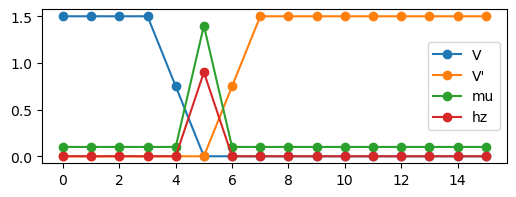

In [18]:
widthD = 5
widthF = 1
widthP = 10

X, Y = widthD+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.5

muD = 0.1 * t
muP = 0.1 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

U = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0 
V_prime[widthF+widthD] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

In [19]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=h)

In [20]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=1000, verbose=False, temperature=T)
F2, Fuu2, Fdd2 = H.get_correlations()

Converged after 126 iterations


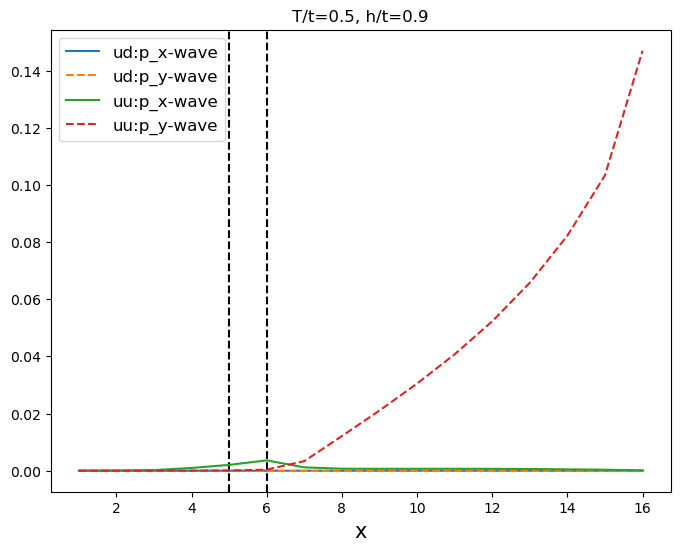

In [21]:
x = np.arange(1, widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, h/t={h0}")
axs.axvline(widthD, color='black', linestyle='--')
axs.axvline(widthD+widthF, color='black', linestyle='--')
# axs.plot(x, np.real(F2.dwave), label="Re(F.dwave)")
# axs.plot(x, np.imag(F2.dwave), label="Im(F.dwave)")
axs.plot(x, np.abs(F2.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F2.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu2.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu2.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)
axs.legend(fontsize=12, loc="best")
plt.savefig('../figures/SFP.pdf')
plt.show()

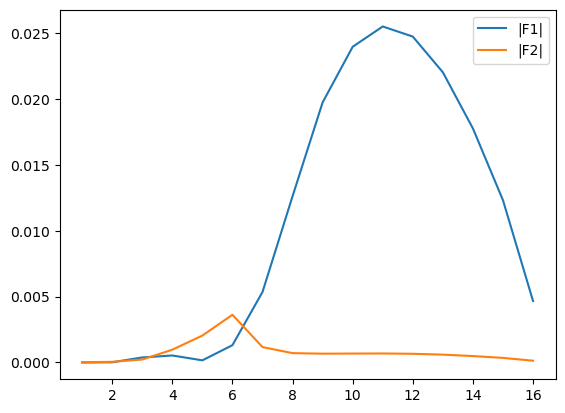

In [22]:
plt.figure()
# plt.plot(x, np.real(F.dwave), label="Re(F.dwave)")
# plt.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
plt.plot(x, np.abs(Fuu.px), label="|F1|")
plt.plot(x, np.abs(Fuu2.px), label="|F2|")
plt.legend()